# **Analiza jakości wina**

## Cel projektu
Które składniki chemiczne wina mają największy wpływ na jego jakość.


# **Słowniczek**
* fixed acidity - kwasowość stała
(Główne, naturalne kwasy pochodzące z winogron)
* volatile acidity - kwasowość lotna (Kwasy powstające podczas fermentacji)
* citric acid - kwas cytrynowy
* residual sugar - cukier resztkowy (Cukier z winogron, który nie zdążył sfermentować w alkohol)
* chlorides - chlorki (zawartość soli w winie)
* free sulfur dioxide - Wolny dwutlenek siarki (Gaz dodawany do wina jako konserwant)
* total sulfur dioxide - Całkowity dwutlenek siarki (Łączna ilość dwutlenku siarki w winie)
* density - gęstość
* pH - pH
* sulphates - siarczany
* alcohol - alkohol
* quality - jakość




In [1]:
import kagglehub

#Pobieramy zbiór danych
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Path to dataset files: /kaggle/input/wine-quality-dataset


In [2]:
import pandas as pd
import numpy as np
import os # Narzędzie do zarządzania ścieżkami plików i folderów na dysku
wine = pd.read_csv(os.path.join(path, 'WineQT.csv')) #wczytuje plik CSV o nazwie 'WineQT.csv' z podanej ścieżki (path) do ramki danych pandas o nazwie df
display(wine.head()) #display ładnie wyświetla

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
wine.describe() #podstawowe statystyki


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
wine["quality"].value_counts()

,count
quality,
5,483
6,462
7,143
4,33
8,16
3,6


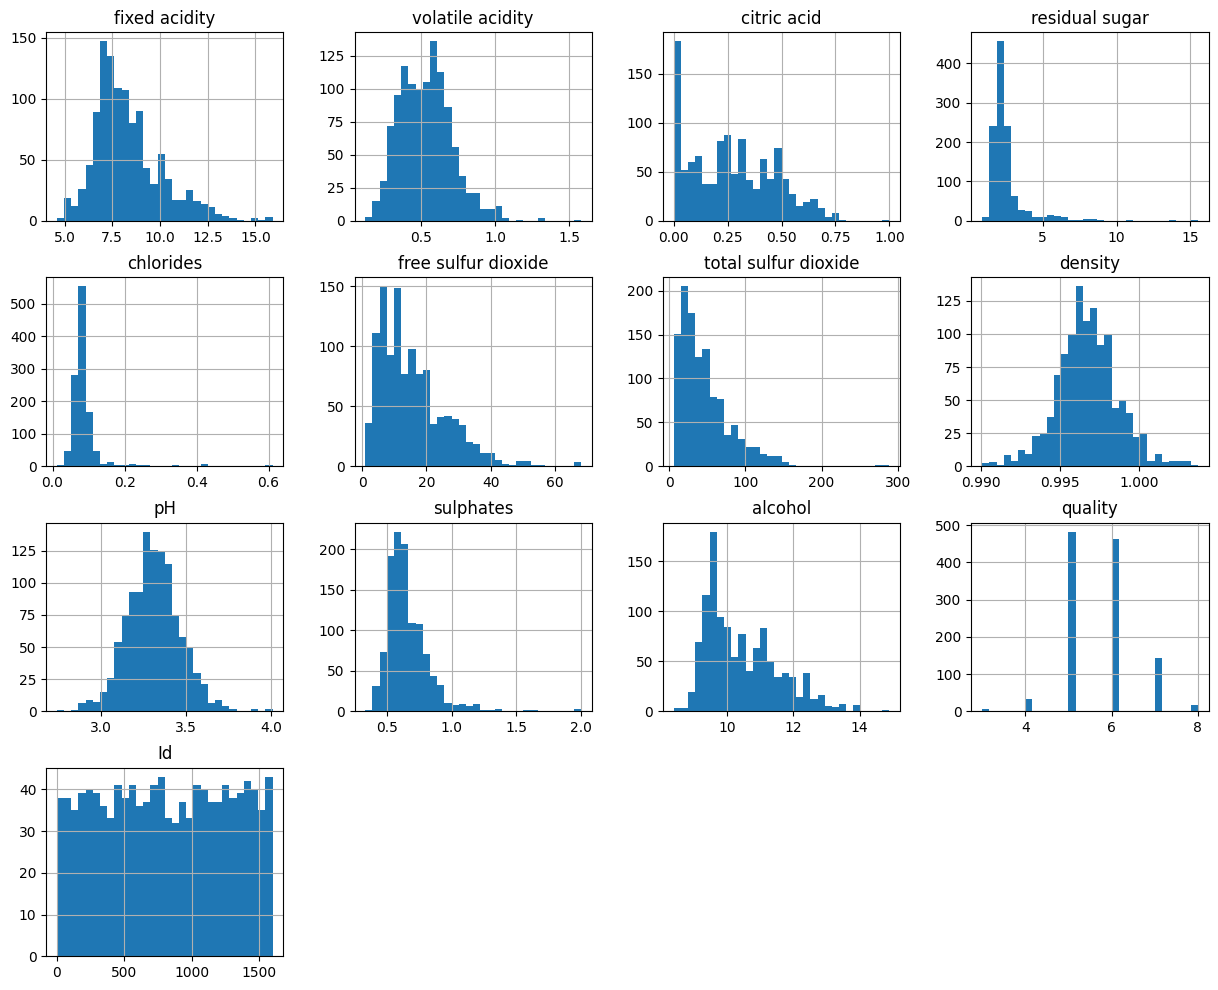

In [6]:
#wizualizacja rozkładu danych w ramce wine za pomocą histogramów
%matplotlib inline
import matplotlib.pyplot as plt
wine.hist(bins=30, figsize=(15,12)) #bins - wykres jest dzielony na tyle słupków
plt.show()

# **Podział na zbiór treningowy i testowy**


In [7]:
#from sklearn.model_selection import train_test_split
#train_set, test_set = train_test_split(wine, test_size=0.2, random_state=42)

In [8]:
wine["quality_cat"] = wine["quality"] #Tworzymy nową, tymczasową kolumnę na kategorie w tabeli wine
wine["quality_cat"] = wine["quality_cat"].clip(lower=4, upper=7)
#ucinamy skrajne, bardzo rzadkie oceny (3 oraz 8), żeby nie popsuć podziału.
#Wszystko co równe lub mniejsze niż 3 dostaje łatkę '4' (lower=4).
#Wszystko co równe lub większe niż 8 dostaje łatkę '7' (upper=7)

In [42]:
#Sprawdzamy rozkład kategorii przed podziałem
wine["quality_cat"].value_counts()

,count
quality_cat,
4,39
7,159
6,462
5,483


In [10]:
#podział na zbiór treningowy i testowy
from sklearn.model_selection import StratifiedShuffleSplit

#Stratyfikowany podział — 80% trening, 20% test
#random_state=42 zapewnia powtarzalność (zawsze ten sam podział)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(wine, wine["quality_cat"]): #tworzymy indeksy do zbioru treningowego i testowego biorąc pod uwagę kolumnę do stratyfikacji
  strat_train_set = wine.loc[train_index]
  strat_test_set = wine.loc[test_index]

In [11]:
#kod oblicza proporcje poszczególnych kategorii jakości wina w zbiorze danych
(wine["quality_cat"].value_counts() / len(wine)).sort_values()

,count
quality_cat,
4,0.034121
7,0.139108
6,0.404199
5,0.422572


In [12]:
#usuwamy kolumnę quality cat ze zbioru treningowego i testowego
for set in (strat_train_set, strat_test_set):
    set.drop(["quality_cat", "Id"], axis=1, inplace=True, errors='ignore') #errors - zapobiega błędowi, jeśli kolumna quality_cat z jakiegoś powodu już nie istnieje w którymś ze zbiorów

In [13]:
#kopia zbioru treningowego i przypisanie do zbioru wine, dzięki temu modyfikacje danych są dokonywane na kopii a nie oryginalnym zbiorez
wine_train = strat_train_set.copy()

In [14]:
wine_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1064,7.1,0.22,0.49,1.8,0.039,8.0,18.0,0.99344,3.39,0.56,12.4,6
728,7.6,0.31,0.34,2.5,0.082,26.0,35.0,0.99356,3.22,0.59,12.5,7
104,7.5,0.60,0.03,1.8,0.095,25.0,99.0,0.99500,3.35,0.54,10.1,5
1039,6.4,0.42,0.09,2.3,0.054,34.0,64.0,0.99724,3.41,0.68,10.4,6
777,7.4,0.49,0.27,2.1,0.071,14.0,25.0,0.99388,3.35,0.63,12.0,6


# **Wizualizacje i korelacje**
Szukamy zależności między cechami a jakością wina. Korelacja bliska +1 oznacza silny pozytywny związek (im więcej, tym lepsza jakość), bliska -1 oznacza silny negatywny (im więcej, tym gorsza jakość).

In [15]:
# Obliczamy współczynnik korelacji liniowej (Pearsona) dla wszystkich kolumn w tabeli wine
macierz_korelacji = wine_train.corr()

# Wyciągamy korelację wszystkich cech względem naszej kolumny docelowej 'quality'
# i sortujemy wyniki malejąco (od najwyższego dodatniego wpływu do ujemnego)
macierz_korelacji["quality"].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.488688
citric acid,0.276220
sulphates,0.260361
fixed acidity,0.148822
residual sugar,0.054959
free sulfur dioxide,-0.067812
pH,-0.094115
chlorides,-0.105048
density,-0.160161


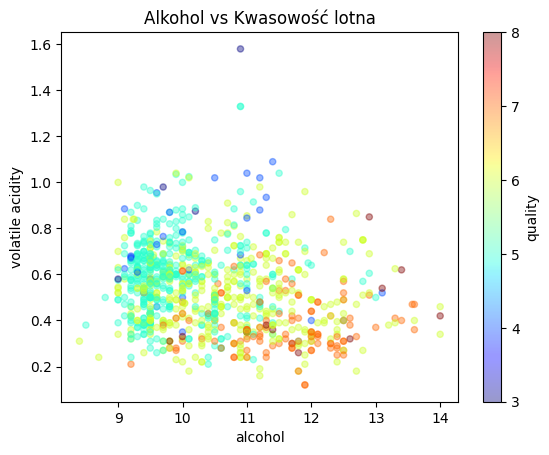

In [16]:
# Wykres rozrzutu: alkohol vs kwasowość lotna, zabarwiony jakością
# Im wyższy alkohol i niższa kwasowość lotna, tym wino ma tendencję do wyższej oceny
wine_train.plot(kind="scatter", x="alcohol", y="volatile acidity", alpha=0.4,
          c="quality", cmap=plt.get_cmap("jet"), colorbar=True,
          title="Alkohol vs Kwasowość lotna")
plt.show()

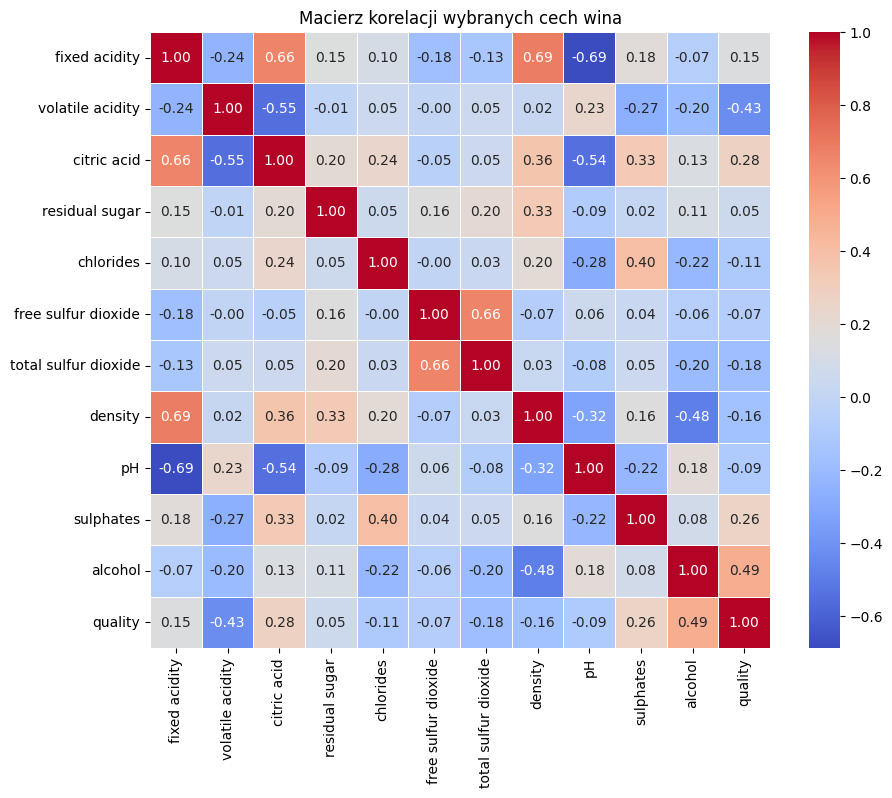

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


#heatmapa korelacji — wizualna macierz korelacji wszystkich cech
plt.figure(figsize=(10, 8))
sns.heatmap(macierz_korelacji, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Macierz korelacji wybranych cech wina")
plt.show()

In [18]:
# Wybieramy 3 kluczowe cechy dla jakości wina na podstawie wcześniejszej analizy korelacji
attributes = ["quality", "alcohol", "volatile acidity", "sulphates"]
wine_train[attributes].corr()

,quality,alcohol,volatile acidity,sulphates
quality,1.000000,0.488688,-0.425402,0.260361
alcohol,0.488688,1.000000,-0.202691,0.079483
volatile acidity,-0.425402,-0.202691,1.000000,-0.267115
sulphates,0.260361,0.079483,-0.267115,1.000000


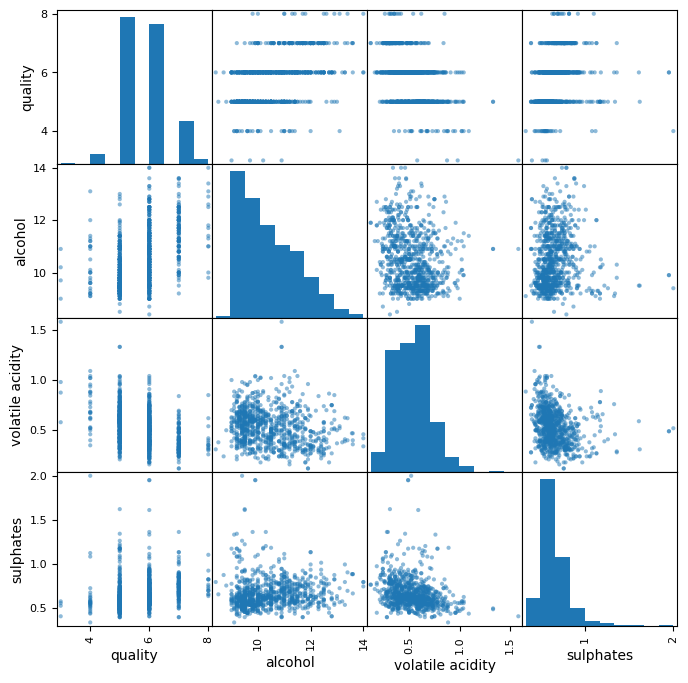

In [19]:
from pandas.plotting import scatter_matrix
attributes = ["quality", "alcohol", "volatile acidity", "sulphates"]

# Rysujemy macierz wykresów rozrzutu, która pokazuje jak te cechy współgrają ze sobą parom
scatter_matrix(wine_train[attributes], figsize=(8, 8))
plt.show()

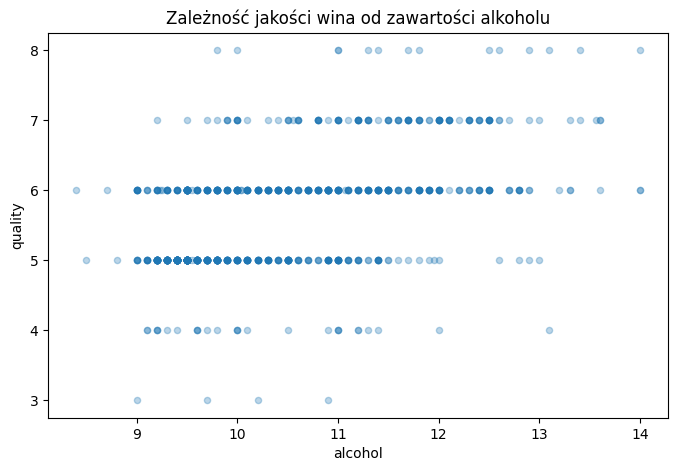

In [20]:
 #Wykres: jak zawartość alkoholu zmienia się wraz z jakością wina?
wine_train.plot(kind="scatter", x="alcohol", y="quality", alpha=0.3, figsize=(8,5), title="Zależność jakości wina od zawartości alkoholu")
plt.show()

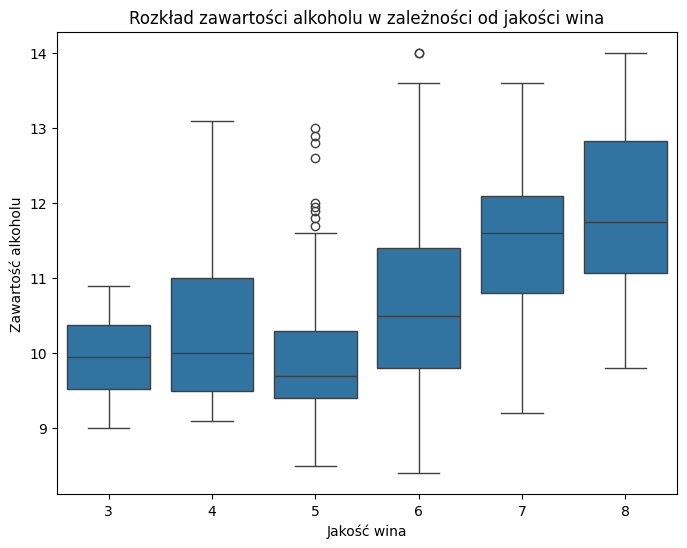

In [21]:
#boxplot: rozkład alkoholu dla każdej oceny jakości
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# x to nasza kategoria (jakość), a y to wartość ciągła (alkohol)
sns.boxplot(x="quality", y="alcohol", data=wine_train)

plt.title("Rozkład zawartości alkoholu w zależności od jakości wina")
plt.xlabel("Jakość wina")
plt.ylabel("Zawartość alkoholu")

plt.show()
#wina z wyższą oceną mają więcej alkoholu

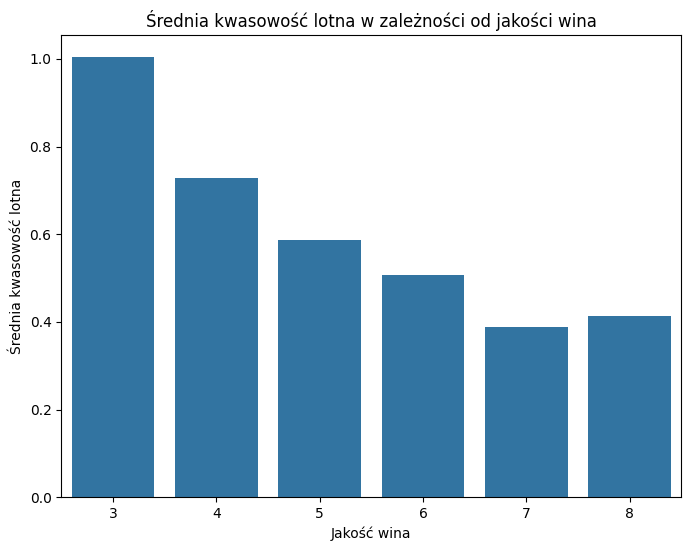

In [22]:
# Wykres słupkowy: średnia kwasowość lotna dla każdej oceny

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# errorbar=None usuwa pionowe linie błędów, żeby wykres był czystszy i bardziej czytelny
sns.barplot(x="quality", y="volatile acidity", data=wine_train, errorbar=None)

plt.title("Średnia kwasowość lotna w zależności od jakości wina")
plt.xlabel("Jakość wina")
plt.ylabel("Średnia kwasowość lotna")

plt.show()
#Wina z wyższą oceną mają wyraźnie niższą kwasowość lotną (mniej 'octowego' posmaku)

# **Tworzenie nowych kolumn**

In [23]:
wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id', 'quality_cat'],
      dtype='object')

Na podstawie analizy korelacji tworzymy 3 nowe cechy złożone, które mogą lepiej opisywać jakość wina niż same oryginalne kolumny. Są to proporcje między istniejącymi cechami, które mają sens chemiczny.

In [24]:
# 1. Proporcja aktywnego konserwantu siarkowego
wine_train["free_sulfur_ratio"] = wine_train["free sulfur dioxide"] / wine_train["total sulfur dioxide"]

# 2. Stosunek kwasowości stabilnej do lotnej (ocet)
wine_train["acid_ratio"] = wine_train["fixed acidity"] / wine_train["volatile acidity"]

# 3. Balans między cukrem a alkoholem
wine_train["sugar_to_alcohol"] = wine_train["residual sugar"] / wine_train["alcohol"]

wine_train.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'free_sulfur_ratio',
       'acid_ratio', 'sugar_to_alcohol'],
      dtype='object')

In [25]:
# Obliczamy nową macierz korelacji uwzględniającą nowe kolumny
corr_mat = wine_train.corr()
corr_mat["quality"].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.488688
acid_ratio,0.385199
citric acid,0.276220
sulphates,0.260361
free_sulfur_ratio,0.177144
fixed acidity,0.148822
residual sugar,0.054959
sugar_to_alcohol,-0.046571
free sulfur dioxide,-0.067812


**Wniosek z analizy korelacji nowych cech:**  
**acid_ratio** pojawia się w czołówce korelacji z jakością, co potwierdza że stosunek kwasów jest istotnym wskaźnikiem jakości. Nowe cechy zostaną uwzględnione w modelu.

# **Data cleaning - pipeline**

In [27]:
wine_train.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [28]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

# Definicja indeksów kolumn, które będą używane do tworzenia nowych cech.
#liczymy od 0, bez ręcznie dodanych kolumn
fixed_acidity_ix, volatile_acidity_ix, residual_sugar_ix, free_sulfur_ix, total_sulfur_ix, alcohol_ix = 0, 1, 3, 5, 6, 10

class CombinedWineAttributesAdder(BaseEstimator, TransformerMixin):
   #dodaje 3 nowe cechy złożone do macierzy danych.
    #Dzięki dziedziczeniu po BaseEstimator i TransformerMixin można go używać bezpośrednio w Pipeline.

    def __init__(self, add_sugar_to_alcohol = True):
      ## Parametr kontrolujący czy dodać cechę sugar_to_alcohol
        self.add_sugar_to_alcohol = add_sugar_to_alcohol

    # Metoda 'fit' jest wymagana przez TransformerMixin, ale w tym przypadku nie wykonuje żadnych operacji, ponieważ transformator nie uczy się niczego na danych treningowych. Zawsze zwraca 'self'.
    def fit(self, X, y=None):
        return self

    # Metoda 'transform' wykonuje główne zadanie - tworzy nowe cechy.
    # X to macierz (lub DataFrame) danych wejściowych.

    def transform(self, X, y=None):
        # 1. free_sulfur_ratio: Stosunek wolnego dwutlenku siarki do całkowitego.
        free_sulfur_ratio = X[:, free_sulfur_ix] / X[:, total_sulfur_ix]

        # 2. acid_ratio: Stosunek kwasowości stałej do lotnej.
        acid_ratio = X[:, fixed_acidity_ix] / X[:, volatile_acidity_ix]

        # Warunkowe dodawanie cechy 'sugar_to_alcohol'.
        if self.add_sugar_to_alcohol:
            # 3. sugar_to_alcohol: Stosunek cukru resztkowego do alkoholu.
            sugar_to_alcohol = X[:, residual_sugar_ix] / X[:, alcohol_ix]

            # np.c_ łączy oryginalną macierz X z nowo utworzonymi kolumnami free_sulfur_ratio, acid_ratio i sugar_to_alcohol.
            return np.c_[X, free_sulfur_ratio, acid_ratio, sugar_to_alcohol]
        else:
            # Jeśli 'add_sugar_to_alcohol' jest False, dodaje tylko dwie cechy.
            return np.c_[X, free_sulfur_ratio, acid_ratio]

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Tylko oryginalne kolumny (11) - bez ręcznie dodanych
# Transformer w pipeline sam je doda automatycznie
original_cols = ['fixed acidity', 'volatile acidity', 'citric acid',
                 'residual sugar', 'chlorides', 'free sulfur dioxide',
                 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

wine_features = wine_train[original_cols] #cechy wejściowe (X)
wine_labels = wine_train["quality"].copy() #zmienna docelowa (Y)

## Definiujemy pipeline — 3 kroki wykonywane automatycznie po kolei
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")), #uzupełnianie braków
    ('attribs_adder', CombinedWineAttributesAdder()), #dodawanie nowych cech
    ('std_scaler', StandardScaler()), #skalowanie
])

#fit_transform: pipeline uczy się na danych treningowych i od razu je przekształca
wine_prepared = num_pipeline.fit_transform(wine_features)

In [30]:
#kształt macierzy - wiersze = próbki, kolumny = 11 oryginalne + 3 nowe = 14
wine_prepared.shape

(914, 14)

In [31]:
pd.DataFrame(wine_prepared)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.718818,-1.744211,1.108413,-0.583767,-0.999963,-0.735465,-0.835315,-1.746367,0.536188,-0.551749,1.844899,0.440779,1.574455,-0.799964
1,-0.429696,-1.243080,0.343548,-0.019107,-0.112076,1.074674,-0.325740,-1.682997,-0.569784,-0.379339,1.939382,2.390256,0.716408,-0.350039
2,-0.487521,0.371675,-1.237174,-0.583767,0.156355,0.974111,1.592659,-0.922557,0.275959,-0.666689,-0.328189,-0.812996,-0.612835,-0.528751
3,-1.123588,-0.630587,-0.931228,-0.180439,-0.690235,1.879180,0.543534,0.260350,0.666302,0.137890,-0.044743,1.007864,-0.309942,-0.176481
4,-0.545345,-0.240818,-0.013389,-0.341770,-0.339210,-0.132086,-0.625490,-1.514011,0.275959,-0.149460,1.466971,1.195683,-0.324993,-0.555152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909,0.900262,0.315994,-1.033210,0.706884,0.300895,1.678054,0.753359,1.797072,0.015730,0.310300,-0.611636,0.481673,-0.139412,0.855524
910,-1.065764,-0.129456,-0.625282,0.384221,-0.483749,-0.333212,-0.565540,-2.031532,0.145845,-0.379339,2.222828,0.440779,-0.585722,-0.068008
911,-0.950115,2.821648,-0.982219,-0.180439,-0.421804,0.370731,-0.415665,-0.140994,1.381930,-0.494279,0.522150,1.416165,-1.282946,-0.275452
912,-0.314048,1.568821,-1.339156,0.061558,-0.277264,3.287066,1.322884,-0.283576,0.471130,-0.206930,0.333186,1.021474,-0.936895,-0.015780


# **Regresja liniowa**
Zakłada, że jakość wina jest liniową kombinacją jego cech.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Tworzymy obiekt modelu
lin_reg = LinearRegression()

# 2. Trenujemy model na naszych przygotowanych danych o winie
lin_reg.fit(wine_prepared, wine_labels)

# 3. Każemy modelowi przewidzieć jakość dla zbioru treningowego
wine_predictions_lin = lin_reg.predict(wine_prepared)

# 4. Obliczamy błąd RMSE (o ile średnio punktów oceny myli się model)
lin_mse = mean_squared_error(wine_labels, wine_predictions_lin)
lin_rmse = np.sqrt(lin_mse)

print(f"RMSE dla modelu regresji liniowej: {lin_rmse}")

RMSE dla modelu regresji liniowej: 0.626356422913513


In [43]:
def display_scores(scores):
  print("Poszczególne błędy:", scores)
  print("Średni błąd modelu:", scores.mean())
  print("Odchylenie standardowe:", scores.std())

In [34]:
from sklearn.model_selection import cross_val_score

#Cross-validation (10-krotna) — bardziej wiarygodna ocena modelu
# Model jest trenowany i testowany 10 razy na różnych podziałach danych
lin_scores = cross_val_score(lin_reg, wine_prepared, wine_labels, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

display_scores(lin_rmse_scores)

Poszczególne błędy: [0.59745496 0.62692847 0.61184663 0.72701119 0.61596609 0.62576533
 0.63730158 0.68897879 0.66695983 0.57509825]
Średni błąd modelu: 0.6373311107187228
Odchylenie standardowe: 0.042893825434124705


Średni błąd RMSE z 10-krotnej walidacji krzyżowej wynosi ok. **0.64**, co oznacza, że model myli się średnio o ok. 0.64 punktu na skali jakości 3–8.

# **Drzewo Decyzyjne**
Drzewo decyzyjne zadaje serię pytań o cechy wina i na tej podstawie przewiduje jakość.

In [35]:
from sklearn.tree import DecisionTreeRegressor

# 1. Inicjalizujemy model Drzewa Decyzyjnego
tree_reg = DecisionTreeRegressor(random_state=42)

# 2. Wykonujemy 10-krotny sprawdzian krzyżowy
tree_scores = cross_val_score(tree_reg, wine_prepared, wine_labels, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)

display_scores(tree_rmse_scores)

Poszczególne błędy: [0.82092207 0.81427482 0.78712465 0.85972695 0.9078413  0.78446454
 0.7914377  0.99449032 0.76316288 0.6953535 ]
Średni błąd modelu: 0.8218798719445534
Odchylenie standardowe: 0.07852773759392917



Średni błąd RMSE z 10-krotnej walidacji krzyżowej wynosi ok **0.82**, co oznacza,
że model myli się średnio o ok. 0.82 punktu na skali jakości 3–8.
Odchylenie standardowe wynosi 0.095, co świadczy o dość stabilnych wynikach
między poszczególnymi podziałami danych.
Pojedyncze drzewo decyzyjne jest podatne na przeuczenie - uczy się zbyt
dokładnie danych treningowych i gorzej radzi sobie z nowymi danymi.

# **Random Forest + Grid Search**
Random forest to zbiór wielu drzew decyzyjnych -> każde drzewo uczy się na losowym wycinku danych i losowym podzbiorze cech. Wynik końcowy to średnia ze wszystkich drzew. Dzięki temu błędy pojedynczych drzew wzajemnie się niwelują.

Grid Search automatycznie testuje wszystkie kombinacje podanych parametrów i wybiera najlepszą

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

#Siatka parametrów do przetestowania — łącznie 13 kombinacji
param_grid = [
    {'n_estimators': [300, 400, 500],'max_features': [8, 10, 11]},   #łącznie 3 x 3 = 9 kombinacji
    {'bootstrap': [False], 'n_estimators': [300, 400], 'max_features': [8, 10]}, #łącznie 2 x 2 = 4 kombinacje
    ]

forest_reg = RandomForestRegressor(random_state=42)

# cv=5 oznacza 5-krotną walidację krzyżową dla każdej kombinacji
# scoring='neg_mean_squared_error' - oceniamy przez ujemny MSE (sklearn maksymalizuje,
# więc zamieniamy znak - najlepszy model ma wartość najbliższą zeru)
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(wine_prepared, wine_labels)

print("Najlepsze parametry:", grid_search.best_params_)

Najlepsze parametry: {'max_features': 8, 'n_estimators': 400}



Grid Search przetestował 13 kombinacji parametrów i wybrał jako najlepsze:
**max_features=8** oraz **n_estimators=400**.
Oznacza to, że każde drzewo przy każdym podziale bierze pod uwagę 8 cech,
a cały las składa się z 400 drzew.
Im więcej drzew, tym bardziej stabilny i dokładny model - błędy pojedynczych
drzew wzajemnie się niwelują.

In [37]:
# Wyciągamy najlepszy model znaleziony przez Grid Search
best_model = grid_search.best_estimator_
best_model

RandomForestRegressor(max_features=8, n_estimators=400, random_state=42)

# **Ocena najlepszego modelu na zbiorze testowym**

In [38]:
#Przygotowujemy zbiór testowy
X_test_clean = strat_test_set[original_cols] # Gwarancja identycznego układu kolumn
y_test = strat_test_set["quality"].copy()

#Usuwamy ręcznie dodane kolumny eksploracyjne — pipeline sam je doda przez transformer
#X_test = X_test_clean.drop(["acid_ratio", "free_sulfur_ratio", "sugar_to_alcohol", "Id"],
                     #axis=1, errors='ignore')

#Przepuszczamy dane testowe przez pipeline (tylko transform — bez uczenia!)
X_test_prepared = num_pipeline.transform(X_test_clean)

#Model przewiduje jakość dla danych testowych
test_pred = best_model.predict(X_test_prepared)

#Obliczamy finalny RMSE
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
print(f"RMSE najlepszego modelu (Random Forest) na zbiorze testowym: {test_rmse:.4f}")

RMSE najlepszego modelu (Random Forest) na zbiorze testowym: 0.6219


# **PORÓWNANIE MODELI**

In [39]:
results = {
    "Regresja liniowa": lin_rmse_scores.mean(),
    "Drzewo decyzyjne": tree_rmse_scores.mean(),
    "Random forest": test_rmse,
}

print("=== PORÓWNANIE MODELI (RMSE — im mniej, tym lepiej) ===")
for name, rmse in results.items():
    print(f"  {name}: {rmse:.4f}")

best_name = min(results, key=results.get)
print(f"\nNajlepszy model: {best_name}")

=== PORÓWNANIE MODELI (RMSE — im mniej, tym lepiej) ===
  Regresja liniowa: 0.6373
  Drzewo decyzyjne: 0.8219
  Random forest: 0.6219

Najlepszy model: Random forest


### Porównanie modeli

| Model | RMSE |
|---|---|
| Regresja liniowa | 0.6373 |
| Drzewo decyzyjne | 0.8219 |
| Random Forest | 0.6219 |

Najlepszym modelem okazał się **Random Forest** z RMSE = 0.6219, co oznacza,
że myli się średnio o ok. 0.62 punktu na skali jakości 3–8.
Drzewo decyzyjne wypadło najgorzej (RMSE = 0.8219) - potwierdza to jego podatność
na przeuczenie. Regresja liniowa dała wynik zbliżony do Random Forest (0.6373),
co sugeruje, że zależności między cechami wina a jego jakością są w dużej mierze liniowe,
jednak Random Forest lepiej uchwycił nieliniowe wzorce w danych.

## **Analiza ważności cech**

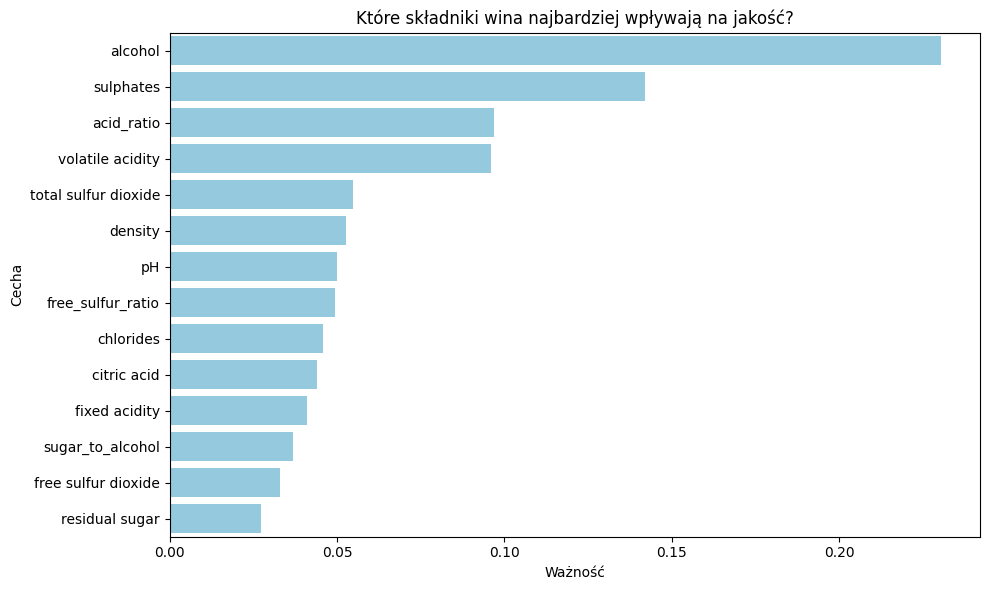

In [41]:
feature_names = ['fixed acidity', 'volatile acidity', 'citric acid',
                 'residual sugar', 'chlorides', 'free sulfur dioxide',
                 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
                 'free_sulfur_ratio', 'acid_ratio', 'sugar_to_alcohol']

#tablica, gdzie każda wartość odpowiada ważności danej cechy w procesie decyzyjnym modelu. Im wyższa wartość, tym większy wpływ ma cecha na przewidywania.
importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Cecha": feature_names,
    "Ważność": importances
}).sort_values("Ważność", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Ważność", y="Cecha", color='skyblue')
plt.title("Które składniki wina najbardziej wpływają na jakość?")
plt.tight_layout()
plt.show()

### Wnioski końcowe

**Najważniejsze składniki wpływające na jakość wina:**
1. **Alkohol** - najsilniejszy czynnik: wina z wyższą zawartością alkoholu są oceniane wyżej
2. **Siarczany** - wpływają korzystnie na aromat i trwałość wina
3. **acid_ratio** - stosunek kwasowości stabilnej do lotnej: im mniej "octowego" posmaku, tym lepsza ocena
4. **Kwasowość lotna** - wysokie wartości świadczą o wadzie wina (smak octu)


